In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## 1. Problem Statement

The objective of this project is to predict whether a Kickstarter
crowdfunding project will be successful or unsuccessful using
machine learning techniques.

The project uses historical Kickstarter campaign information such
as funding goal, campaign duration, category, country, currency,
launch information, and project-name characteristics to build
classification models.


In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Find the dataset
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/thaidatta/machine-learning/ks-projects-201801.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/thaidatta/machine-learning/ks-projects-201801.csv')

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (378661, 15)


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


## 2. Dataset

The dataset contains 378,661 Kickstarter projects with 15 original
attributes.

Important attributes include project category, main category,
currency, funding goal, launch date, deadline, pledged amount,
number of backers, country, and project state.

The target variable is created by classifying completed projects
into:
- 0: Failed
- 1: Successful

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
for col in df.columns:
    print(col)

Number of rows: 378661
Number of columns: 15

Column Names:
ID
name
category
main_category
currency
deadline
goal
launched
pledged
state
backers
country
usd pledged
usd_pledged_real
usd_goal_real


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             378661 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


In [5]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,378661.0,NaN,NaN,NaN,1074731191.988755,619086204.322627,5971.0,538263516.0,1075275634.0,1610148624.0,2147476221.0
name,378657,375764,New EP/Music Development,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,378661,159,Product Design,22314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_category,378661,15,Film & Video,63585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
currency,378661,14,USD,295365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deadline,378661,3164,2014-08-08,705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
goal,378661.0,NaN,NaN,NaN,49080.791521,1183391.259093,0.01,2000.0,5200.0,16000.0,100000000.0
launched,378661,378089,1970-01-01 01:00:00,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pledged,378661.0,NaN,NaN,NaN,9682.979339,95636.010005,0.0,30.0,620.0,4076.0,20338986.27
state,378661,6,failed,197719,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print(df['state'].value_counts())

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64


In [7]:
# Keep only successful and failed projects
df = df[df['state'].isin(['successful', 'failed'])].copy()

# Create binary target
df['target'] = df['state'].map({
    'successful': 1,
    'failed': 0
})

print("New dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts())

print("\nTarget percentage:")
print(df['target'].value_counts(normalize=True) * 100)

New dataset shape: (331675, 16)

Target distribution:
target
0    197719
1    133956
Name: count, dtype: int64

Target percentage:
target
0    59.612271
1    40.387729
Name: proportion, dtype: float64


In [8]:
# Convert date columns
df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])

# Campaign duration in days
df['campaign_duration'] = (
    df['deadline'] - df['launched']
).dt.total_seconds() / (24 * 60 * 60)

# Launch date features
df['launch_year'] = df['launched'].dt.year
df['launch_month'] = df['launched'].dt.month
df['launch_dayofweek'] = df['launched'].dt.dayofweek

print(df[['launched', 'deadline', 'campaign_duration',
          'launch_year', 'launch_month',
          'launch_dayofweek']].head())

             launched   deadline  campaign_duration  launch_year  \
0 2015-08-11 12:12:28 2015-10-09          58.491343         2015   
1 2017-09-02 04:43:57 2017-11-01          59.802813         2017   
2 2013-01-12 00:20:50 2013-02-26          44.985532         2013   
3 2012-03-17 03:24:11 2012-04-16          29.858206         2012   
5 2016-02-26 13:38:27 2016-04-01          34.431632         2016   

   launch_month  launch_dayofweek  
0             8                 1  
1             9                 5  
2             1                 5  
3             3                 5  
5             2                 4  


In [9]:
print("Invalid/early launch dates:")
print((df['launched'].dt.year < 2009).sum())

print("\nCampaign duration statistics:")
print(df['campaign_duration'].describe())

Invalid/early launch dates:
0

Campaign duration statistics:
count    331675.000000
mean         33.389378
std          12.723385
min           0.005058
25%          29.088929
50%          29.656759
75%          35.705966
max          91.962650
Name: campaign_duration, dtype: float64


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
ID                     0
name                   3
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged          210
usd_pledged_real       0
usd_goal_real          0
target                 0
campaign_duration      0
launch_year            0
launch_month           0
launch_dayofweek       0
dtype: int64


In [11]:
print("Invalid/early launch dates:")
print((df['launched'].dt.year < 2009).sum())

print("\nCampaign duration statistics:")
print(df['campaign_duration'].describe())

print("\nMissing values:")
print(df.isnull().sum())

Invalid/early launch dates:
0

Campaign duration statistics:
count    331675.000000
mean         33.389378
std          12.723385
min           0.005058
25%          29.088929
50%          29.656759
75%          35.705966
max          91.962650
Name: campaign_duration, dtype: float64

Missing values:
ID                     0
name                   3
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state                  0
backers                0
country                0
usd pledged          210
usd_pledged_real       0
usd_goal_real          0
target                 0
campaign_duration      0
launch_year            0
launch_month           0
launch_dayofweek       0
dtype: int64


## 3. Data Preprocessing

The dataset was inspected for missing values, invalid dates,
duplicate or unsuitable campaign states, and inconsistent records.

Campaign start and deadline dates were converted into datetime
format. Campaign duration was calculated from the difference
between the deadline and launch date.

Projects with non-final states such as live, undefined, and
suspended were excluded from the classification task.

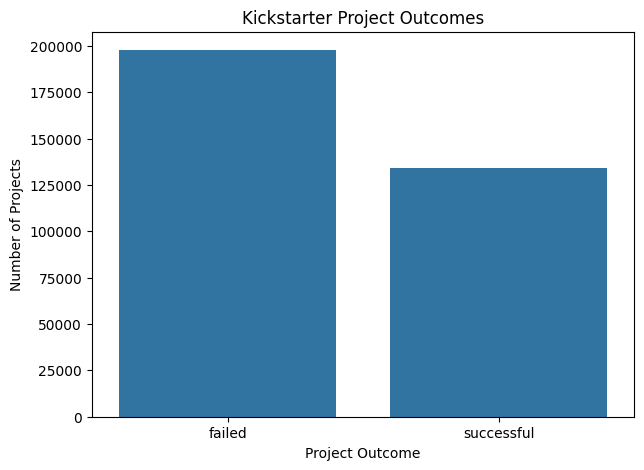

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='state'
)

plt.title('Kickstarter Project Outcomes')
plt.xlabel('Project Outcome')
plt.ylabel('Number of Projects')
plt.show()

In [13]:
success_rate = df['target'].value_counts(normalize=True) * 100

print("Failure :", round(success_rate[0], 2), "%")
print("Success :", round(success_rate[1], 2), "%")

Failure : 59.61 %
Success : 40.39 %


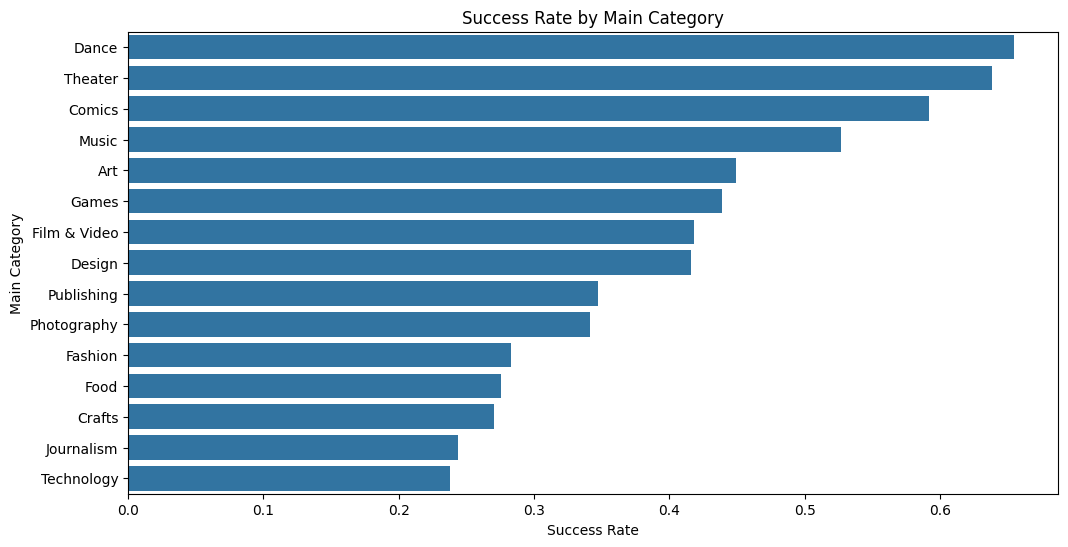

In [14]:
category_success = (
    df.groupby('main_category')['target']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_success.values,
    y=category_success.index
)

plt.title('Success Rate by Main Category')
plt.xlabel('Success Rate')
plt.ylabel('Main Category')

plt.show()

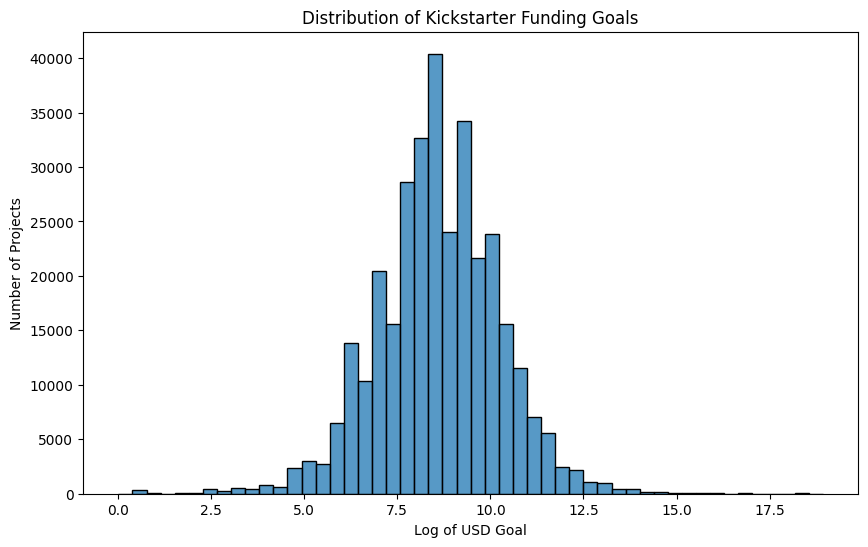

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df['usd_goal_real']),
    bins=50
)

plt.title('Distribution of Kickstarter Funding Goals')
plt.xlabel('Log of USD Goal')
plt.ylabel('Number of Projects')

plt.show()

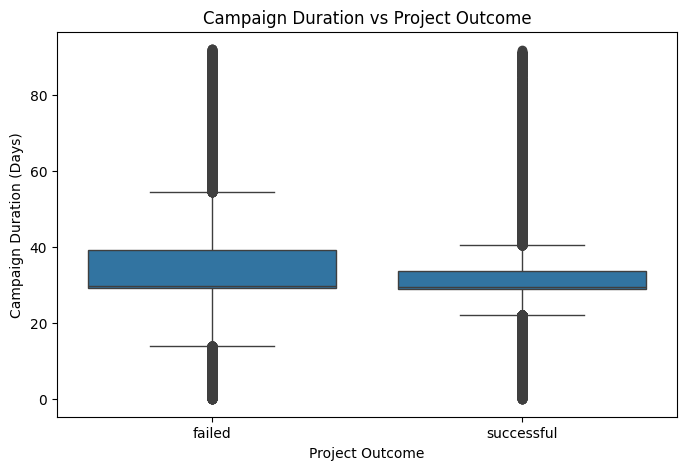

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='state',
    y='campaign_duration'
)

plt.title('Campaign Duration vs Project Outcome')
plt.xlabel('Project Outcome')
plt.ylabel('Campaign Duration (Days)')

plt.show()

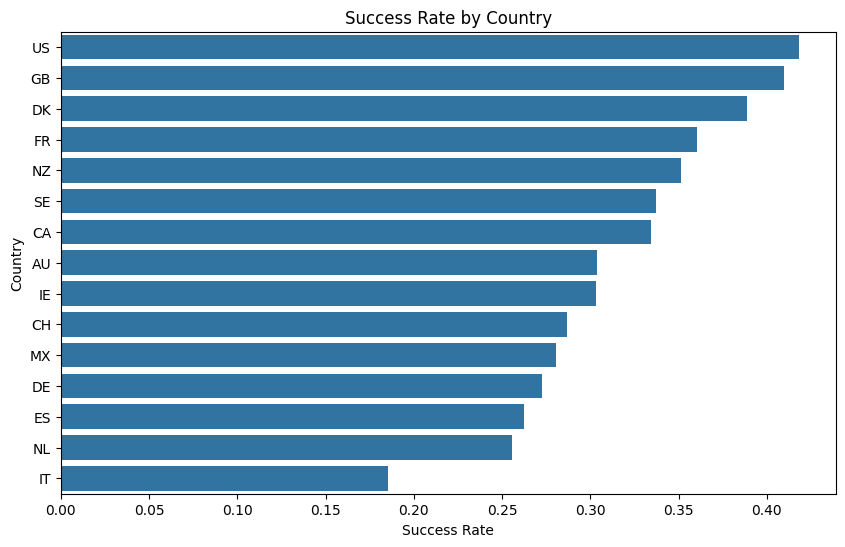

In [17]:
top_countries = df['country'].value_counts().head(15).index

country_success = (
    df[df['country'].isin(top_countries)]
    .groupby('country')['target']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=country_success.values,
    y=country_success.index
)

plt.title('Success Rate by Country')
plt.xlabel('Success Rate')
plt.ylabel('Country')

plt.show()

In [18]:
# Create a copy for machine learning
ml_df = df.copy()

# Log-transform the funding goal
ml_df['log_goal'] = np.log1p(ml_df['usd_goal_real'])

# Select features available at/around project launch
features = [
    'category',
    'main_category',
    'currency',
    'country',
    'log_goal',
    'campaign_duration',
    'launch_year',
    'launch_month',
    'launch_dayofweek'
]

X = ml_df[features]
y = ml_df['target']

print("Feature shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (331675, 9)

Features:
['category', 'main_category', 'currency', 'country', 'log_goal', 'campaign_duration', 'launch_year', 'launch_month', 'launch_dayofweek']

Target shape: (331675,)

Target distribution:
target
0    197719
1    133956
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 265340
Testing samples: 66335

Training target distribution:
target
0    0.596122
1    0.403878
Name: proportion, dtype: float64

Testing target distribution:
target
0    0.596126
1    0.403874
Name: proportion, dtype: float64


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    'category',
    'main_category',
    'currency',
    'country'
]

numerical_features = [
    'log_goal',
    'campaign_duration',
    'launch_year',
    'launch_month',
    'launch_dayofweek'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [21]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

In [22]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

start = time.time()

logistic_model.fit(X_train, y_train)

logistic_time = time.time() - start

print(f"Training time: {logistic_time:.2f} seconds")

Training time: 3.29 seconds


In [23]:
y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Logistic Regression
-------------------
Accuracy : 0.6573754428280697
Precision: 0.563990298295902
Recall   : 0.6683214512336232
F1 Score : 0.6117393829649117


In [24]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Failed', 'Successful']
))

              precision    recall  f1-score   support

      Failed       0.74      0.65      0.69     39544
  Successful       0.56      0.67      0.61     26791

    accuracy                           0.66     66335
   macro avg       0.65      0.66      0.65     66335
weighted avg       0.67      0.66      0.66     66335



In [25]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

start = time.time()

rf_model.fit(X_train, y_train)

rf_time = time.time() - start

print(f"Training time: {rf_time:.2f} seconds")

Training time: 23.12 seconds


In [26]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("-------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest
-------------
Accuracy : 0.6640536669932916
Precision: 0.5742633001516251
Recall   : 0.6502930088462543
F1 Score : 0.6099179050919848


In [27]:
from sklearn.preprocessing import OrdinalEncoder

gb_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            categorical_features
        )
    ]
)

In [28]:
gb_model = Pipeline([
    ('preprocessor', gb_preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

start = time.time()

gb_model.fit(X_train, y_train)

gb_time = time.time() - start

print(f"Training time: {gb_time:.2f} seconds")

Training time: 41.03 seconds


In [29]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting")
print("-----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

Gradient Boosting
-----------------
Accuracy : 0.6786311901711012
Precision: 0.6450877472032236
Recall   : 0.4541450487103878
F1 Score : 0.5330325067905021


In [30]:
from sklearn.model_selection import train_test_split

X_svm, _, y_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=40000,
    random_state=42,
    stratify=y_train
)

print("SVM training samples:", X_svm.shape[0])

SVM training samples: 40000


In [31]:
svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        class_weight='balanced'
    ))
])

start = time.time()

svm_model.fit(X_svm, y_svm)

svm_time = time.time() - start

print(f"Training time: {svm_time:.2f} seconds")

Training time: 101.88 seconds


In [32]:
y_pred_svm = svm_model.predict(X_test)

print("SVM")
print("---")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

SVM
---
Accuracy : 0.6608879173890103
Precision: 0.5648589890693883
Recall   : 0.6982568773095442
F1 Score : 0.6245138459997663


In [33]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_svm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_svm)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_svm)
    ]
})

results = results.sort_values(
    by='F1 Score',
    ascending=False
).reset_index(drop=True)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.660888,0.564859,0.698257,0.624514
1,Logistic Regression,0.657375,0.563990,0.668321,0.611739
2,Random Forest,0.664054,0.574263,0.650293,0.609918
3,Gradient Boosting,0.678631,0.645088,0.454145,0.533033


In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

models_predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'SVM': y_pred_svm
}

for name, predictions in models_predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, predictions))


Logistic Regression
[[25702 13842]
 [ 8886 17905]]

Random Forest
[[26628 12916]
 [ 9369 17422]]

Gradient Boosting
[[32850  6694]
 [14624 12167]]

SVM
[[25133 14411]
 [ 8084 18707]]


<Figure size 600x500 with 0 Axes>

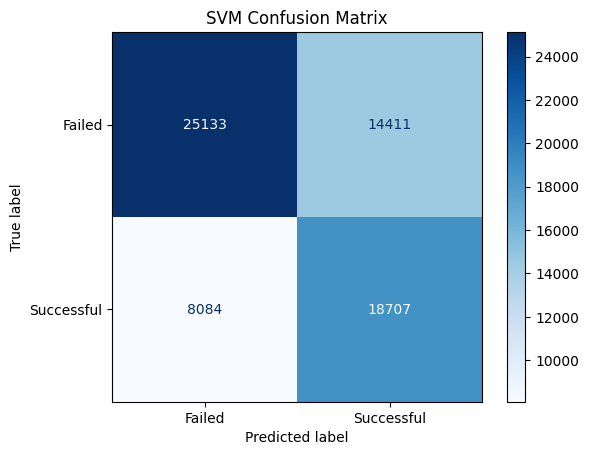

In [35]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=['Failed', 'Successful'],
    cmap='Blues'
)

plt.title('SVM Confusion Matrix')
plt.show()

## 4. Exploratory Data Analysis

Exploratory data analysis was performed to understand the
distribution of successful and failed projects and to identify
patterns related to category, country, funding goal, and campaign
duration.

The analysis showed that failed projects form the majority of the
dataset, while approximately 40% of the completed projects were
successful.

In [50]:
# ============================================================
# IMPROVED FEATURE ENGINEERING - LEAKAGE SAFE
# ============================================================

import pandas as pd
import numpy as np

ml_df = df.copy()

# ------------------------------------------------------------
# Basic date features
# ------------------------------------------------------------
ml_df['deadline'] = pd.to_datetime(ml_df['deadline'])
ml_df['launched'] = pd.to_datetime(ml_df['launched'])

ml_df['campaign_duration'] = (
    ml_df['deadline'] - ml_df['launched']
).dt.total_seconds() / (24 * 60 * 60)

ml_df['launch_year'] = ml_df['launched'].dt.year
ml_df['launch_month'] = ml_df['launched'].dt.month
ml_df['launch_dayofweek'] = ml_df['launched'].dt.dayofweek

# ------------------------------------------------------------
# Log funding goal
# ------------------------------------------------------------
ml_df['log_goal'] = np.log1p(ml_df['usd_goal_real'])

# ------------------------------------------------------------
# Goal required per campaign day
# ------------------------------------------------------------
ml_df['goal_per_day'] = (
    ml_df['usd_goal_real'] /
    ml_df['campaign_duration'].clip(lower=1)
)

ml_df['log_goal_per_day'] = np.log1p(
    ml_df['goal_per_day']
)

# ------------------------------------------------------------
# Project name features
# ------------------------------------------------------------
ml_df['name'] = ml_df['name'].fillna('')

ml_df['name_length'] = ml_df['name'].str.len()

ml_df['name_word_count'] = (
    ml_df['name'].str.split().str.len()
)

ml_df['name_exclamation'] = (
    ml_df['name'].str.count('!')
)

ml_df['name_question'] = (
    ml_df['name'].str.count(r'\?')
)

# ------------------------------------------------------------
# Final feature list WITHOUT frequency features for now
# ------------------------------------------------------------

features = [
    'category',
    'main_category',
    'currency',
    'country',

    'log_goal',
    'log_goal_per_day',
    'campaign_duration',

    'launch_year',
    'launch_month',
    'launch_dayofweek',

    'name_length',
    'name_word_count',
    'name_exclamation',
    'name_question'
]

X = ml_df[features].copy()
y = ml_df['target'].copy()

print("Feature engineering completed.")
print("Feature count:", len(features))
print("Dataset shape:", X.shape)
print("\nFeatures:")
print(features)

Feature engineering completed.
Feature count: 14
Dataset shape: (331675, 14)

Features:
['category', 'main_category', 'currency', 'country', 'log_goal', 'log_goal_per_day', 'campaign_duration', 'launch_year', 'launch_month', 'launch_dayofweek', 'name_length', 'name_word_count', 'name_exclamation', 'name_question']


## 5. Feature Engineering

Additional features were created to improve the predictive
capability of the models.

These include:
- Log-transformed funding goal
- Log-transformed goal per campaign day
- Campaign duration
- Launch year, month, and day of week
- Project name length
- Project name word count
- Number of exclamation marks
- Number of question marks

Categorical variables were encoded using One-Hot Encoding and
numerical variables were standardized using StandardScaler.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 265340
Testing samples: 66335


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (265340, 18)
Testing : (66335, 18)


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    'category',
    'main_category',
    'currency',
    'country'
]

numerical_features = [
    'log_goal',
    'log_goal_per_day',
    'campaign_duration',
    'launch_year',
    'launch_month',
    'launch_dayofweek',
    'name_length',
    'name_word_count',
    'name_exclamation',
    'name_question'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("Preprocessor ready.")

Preprocessor ready.


In [53]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression")
print("-------------------")

Logistic Regression
-------------------


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [63]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

gb_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            categorical_features
        )
    ]
)

gb_model = Pipeline([
    ('preprocessor', gb_preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting completed.")

Gradient Boosting completed.


In [64]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

linear_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=3000,
        random_state=42
    ))
])

linear_svm.fit(X_train, y_train)

y_pred_linear_svm = linear_svm.predict(X_test)

print("Linear SVM completed!")

Linear SVM completed!


## 6. Model Training

Four classification algorithms were evaluated:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. Linear SVM

The dataset was divided into training and testing sets using an
80:20 stratified split.

In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Linear SVM Results")
print("------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred_linear_svm), 4))
print("Precision:", round(precision_score(y_test, y_pred_linear_svm), 4))
print("Recall   :", round(recall_score(y_test, y_pred_linear_svm), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_linear_svm), 4))

Linear SVM Results
------------------
Accuracy : 0.6635
Precision: 0.57
Recall   : 0.6794
F1 Score : 0.6199


In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

final_results = []

# Existing improved models
predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'Linear SVM': y_pred_linear_svm
}

for name, pred in predictions.items():
    final_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred)
    })

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df.sort_values(
    'F1 Score',
    ascending=False
).reset_index(drop=True)

display(final_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.6679,0.5728,0.6991,0.6297
1,Linear SVM,0.6635,0.5700,0.6794,0.6199
2,Logistic Regression,0.6633,0.5698,0.6790,0.6196
3,Gradient Boosting,0.6961,0.6466,0.5456,0.5918


## 7. Model Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC

These metrics were used to compare the models and determine the
most suitable approach for predicting Kickstarter project success.

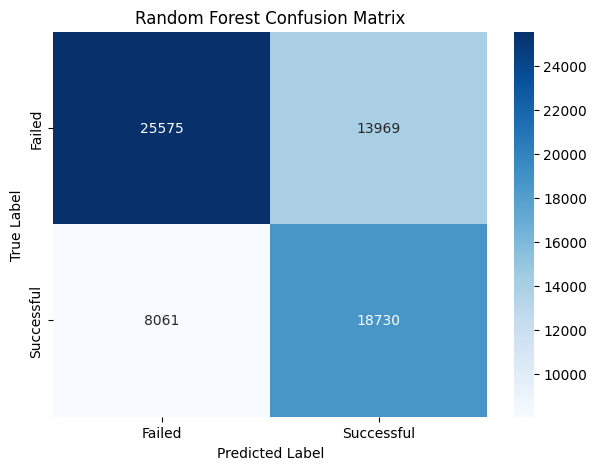

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

      Failed       0.76      0.65      0.70     39544
  Successful       0.57      0.70      0.63     26791

    accuracy                           0.67     66335
   macro avg       0.67      0.67      0.66     66335
weighted avg       0.68      0.67      0.67     66335



In [66]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest predictions
y_pred_final = y_pred_rf

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Failed', 'Successful'],
    yticklabels=['Failed', 'Successful']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Classification Report
print("Random Forest Classification Report")
print("------------------------------------")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Failed', 'Successful']
))

Random Forest ROC-AUC: 0.7403


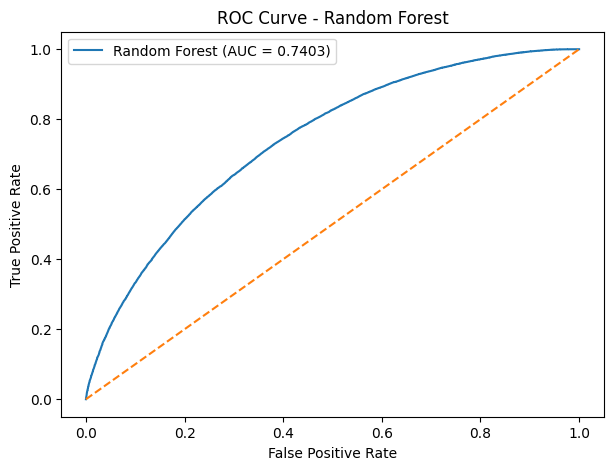

In [67]:
# Get probability predictions
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(roc_auc, 4))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

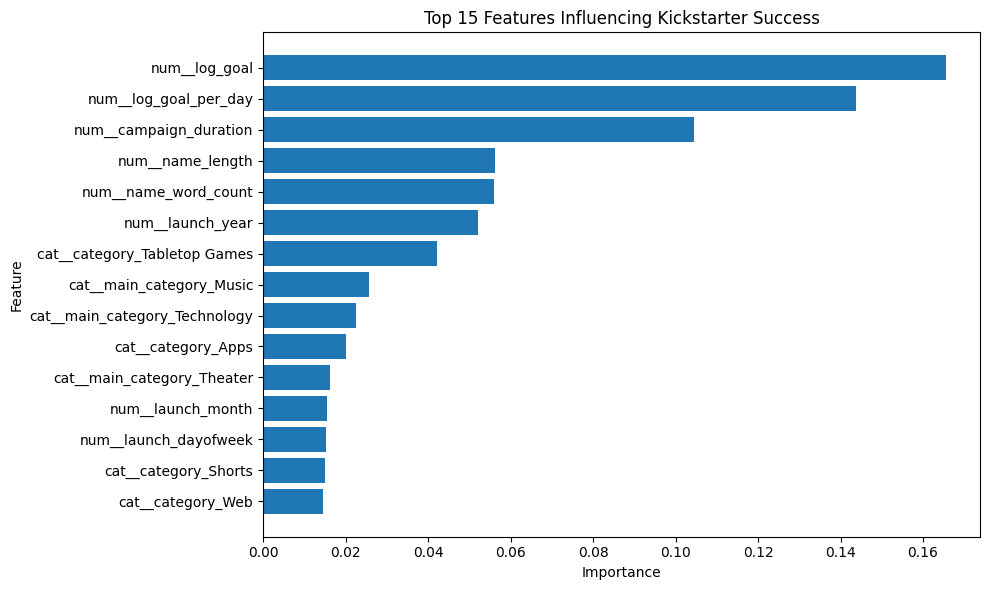

,Feature,Importance
0,num__log_goal,0.165546
1,num__log_goal_per_day,0.143682
2,num__campaign_duration,0.104417
6,num__name_length,0.056308
7,num__name_word_count,0.055870
3,num__launch_year,0.052048
146,cat__category_Tabletop Games,0.042202
179,cat__main_category_Music,0.025590
182,cat__main_category_Technology,0.022517
18,cat__category_Apps,0.020198


In [68]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance
importances = rf_model.named_steps['classifier'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features Influencing Kickstarter Success')
plt.tight_layout()
plt.show()

display(feature_importance)

## 8. Results

Gradient Boosting achieved the highest accuracy, while Random Forest
achieved the strongest balance between recall and F1 score for
identifying successful projects.

Random Forest achieved:
- Accuracy: 66.79%
- Precision: 57.28%
- Recall: 69.91%
- F1 Score: 62.97%
- ROC-AUC: approximately 0.74

Feature importance analysis showed that funding goal, funding
required per campaign day, and campaign duration were among the
most influential features.

## 9. Conclusion

This project demonstrates the use of machine learning to predict
Kickstarter crowdfunding project success.

The experiments showed that funding requirements, campaign duration,
launch information, project characteristics, and category contribute
to predicting campaign outcomes.

Among the evaluated models, Random Forest provided a strong balance
between recall and F1 score for identifying successful projects,
while Gradient Boosting achieved the highest overall accuracy.

The results demonstrate that historical crowdfunding data can be
used to identify patterns associated with campaign success.